In [ ]:
import pandas as pd
import numpy as np

### ***Load cleaned NAV data***

In [ ]:
nav = pd.read_csv('02_nav_history_cleaned.csv')
nav['date'] = pd.to_datetime(nav['date'])

print(nav.shape)
print(nav.head())

(64320, 3)
        date  amfi_code       nav
0 2022-01-03     100016  520.4608
1 2022-01-04     100016  515.0971
2 2022-01-05     100016  521.7239
3 2022-01-06     100016  515.7880
4 2022-01-07     100016  515.1639


### ***Sort data by amfi_code + date***

In [ ]:
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)
print(nav.head())

        date  amfi_code       nav
0 2022-01-03     100016  520.4608
1 2022-01-04     100016  515.0971
2 2022-01-05     100016  521.7239
3 2022-01-06     100016  515.7880
4 2022-01-07     100016  515.1639


### ***Compute daily returns (pct_change())***

In [ ]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
print(nav.head(10))

        date  amfi_code       nav  daily_return
0 2022-01-03     100016  520.4608           NaN
1 2022-01-04     100016  515.0971     -0.010306
2 2022-01-05     100016  521.7239      0.012865
3 2022-01-06     100016  515.7880     -0.011377
4 2022-01-07     100016  515.1639     -0.001210
5 2022-01-08     100016  515.1639      0.000000
6 2022-01-09     100016  515.1639      0.000000
7 2022-01-10     100016  510.7136     -0.008639
8 2022-01-11     100016  513.5542      0.005562
9 2022-01-12     100016  512.3195     -0.002404


***Summary statistics***

In [ ]:
print(nav['daily_return'].describe())

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64


### ***Find the extreme outlier***

In [ ]:
extreme_day = nav[nav['daily_return'] == nav['daily_return'].min()]
print(extreme_day)

            date  amfi_code      nav  daily_return
17860 2022-06-24     118634  67.2534     -0.058102


### ***Build and test the calculate_cagr() function***

In [ ]:
def calculate_cagr(nav_df, amfi_code, years):
    scheme_data = nav_df[nav_df['amfi_code'] == amfi_code].sort_values('date')
    end_date = scheme_data['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    start_row = scheme_data[scheme_data['date'] >= start_date].iloc[0]
    end_row = scheme_data.iloc[-1]
    nav_start = start_row['nav']
    nav_end = end_row['nav']
    actual_years = (end_row['date'] - start_row['date']).days / 365.25
    cagr = (nav_end / nav_start) ** (1 / actual_years) - 1
    return cagr
test_cagr = calculate_cagr(nav, 100016, 3)
print(f"3-year CAGR for scheme 100016: {test_cagr:.4f} ({test_cagr*100:.2f}%)")

3-year CAGR for scheme 100016: 0.0129 (1.29%)


***Loop calculate_cagr() across all 40 schemes for 1yr/3yr/5yr, merge in fund names***

In [ ]:
fund_info = pd.read_csv('01_fund_master_cleaned.csv')
# Calculate 1yr, 3yr, 5yr CAGR for every scheme
cagr_results = []

for code in nav['amfi_code'].unique():
    row = {'amfi_code': code}
    for yrs in [1, 3, 5]:
        try:
            row[f'cagr_{yrs}yr'] = calculate_cagr(nav, code, yrs)
        except Exception as e:
            row[f'cagr_{yrs}yr'] = None
    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)
cagr_df = cagr_df.merge(fund_info[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code', how='left')

print(cagr_df.shape)
print(cagr_df.head(10))

(40, 6)
   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr  \
0     100016 -0.022258  0.012924  0.026371   
1     100025  0.037076  0.039155  0.044582   
2     100033  0.532772  0.324340  0.301232   
3     101206  0.479638  0.289602  0.235384   
4     101207 -0.240003 -0.041515  0.079388   
5     101208  0.072418  0.063143  0.065090   
6     102885  0.202229  0.196624  0.182324   
7     102886 -0.168080 -0.007672  0.011717   
8     102887  0.135930  0.255497  0.168411   
9     118632  0.340079  0.226466  0.240495   

                                         scheme_name                fund_house  
0          HDFC Top 100 Fund - Regular Plan - Growth          HDFC Mutual Fund  
1       HDFC Short Term Debt Fund - Regular - Growth          HDFC Mutual Fund  
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...          HDFC Mutual Fund  
3      ABSL Frontline Equity Fund - Regular - Growth  Aditya Birla Sun Life MF  
4             ABSL Small Cap Fund - Regular - Growth  Aditya Birla Sun Life MF  

In [ ]:
print(cagr_df[['cagr_1yr', 'cagr_3yr', 'cagr_5yr']].isna().sum())
print()
print(cagr_df[['cagr_1yr', 'cagr_3yr', 'cagr_5yr']].describe())

cagr_1yr    0
cagr_3yr    0
cagr_5yr    0
dtype: int64

        cagr_1yr   cagr_3yr   cagr_5yr
count  40.000000  40.000000  40.000000
mean    0.194445   0.164105   0.167357
std     0.229306   0.122036   0.103090
min    -0.428195  -0.117033   0.011717
25%     0.073832   0.065994   0.068618
50%     0.174871   0.182286   0.166073
75%     0.271826   0.268957   0.244883
max     0.828516   0.351025   0.328274


### ***Build a helper function for Max Drawdown, one scheme at a time***

In [ ]:
def calculate_max_drawdown(nav_df, amfi_code):
    scheme_data = nav_df[nav_df['amfi_code'] == amfi_code].sort_values('date').copy()
    scheme_data['running_max'] = scheme_data['nav'].cummax()
    scheme_data['drawdown'] = scheme_data['nav'] / scheme_data['running_max'] - 1
    max_dd = scheme_data['drawdown'].min()
    trough_row = scheme_data[scheme_data['drawdown'] == max_dd].iloc[0]
    trough_date = trough_row['date']
    peak_nav = trough_row['running_max']
    peak_candidates = scheme_data[(scheme_data['date'] <= trough_date) & (scheme_data['nav'] == peak_nav)]
    peak_date = peak_candidates['date'].max()
    return max_dd, peak_date, trough_date
test_dd, test_peak, test_trough = calculate_max_drawdown(nav, 100016)
print(f"Max Drawdown: {test_dd:.4f} ({test_dd*100:.2f}%)")
print(f"Peak date: {test_peak.date()}")
print(f"Trough date: {test_trough.date()}")

Max Drawdown: -0.2473 (-24.73%)
Peak date: 2022-03-30
Trough date: 2022-09-15


### ***Calculate Max Drawdown for every fund***

In [ ]:
dd_results = []
for code in nav['amfi_code'].unique():
    max_dd, peak_date, trough_date = calculate_max_drawdown(nav, code)
    dd_results.append({
        'amfi_code': code,
        'max_drawdown': max_dd,
        'peak_date': peak_date,
        'trough_date': trough_date})
dd_df = pd.DataFrame(dd_results)
dd_df = dd_df.merge(fund_info[['amfi_code', 'scheme_name', 'fund_house', 'sub_category']], on='amfi_code', how='left')
dd_df = dd_df.sort_values('max_drawdown')
print(dd_df.shape)
print(dd_df.head(10))

(40, 7)
    amfi_code  max_drawdown  peak_date trough_date  \
22     119599     -0.525742 2023-01-17  2025-10-28   
17     119095     -0.516778 2025-05-22  2026-05-11   
4      101207     -0.354469 2024-11-21  2026-05-11   
39     149324     -0.311719 2024-05-05  2025-01-03   
21     119598     -0.287060 2024-08-28  2025-05-14   
7      102886     -0.280011 2025-01-07  2026-04-27   
0      100016     -0.247344 2022-03-30  2022-09-15   
29     120842     -0.240035 2023-11-09  2024-10-17   
11     118634     -0.233449 2025-04-09  2026-02-20   
15     119093     -0.217514 2022-02-24  2023-05-22   

                                       scheme_name                fund_house  \
22       SBI Small Cap Fund - Direct Plan - Growth           SBI Mutual Fund   
17          Axis Small Cap Fund - Regular - Growth          Axis Mutual Fund   
4           ABSL Small Cap Fund - Regular - Growth  Aditya Birla Sun Life MF   
39           DSP Small Cap Fund - Regular - Growth           DSP Mutual Fund 

In [ ]:
print(dd_df.sort_values('max_drawdown', ascending=False).head(5)[['scheme_name', 'sub_category', 'max_drawdown']])

                                     scheme_name    sub_category  max_drawdown
27      ICICI Pru Liquid Fund - Regular - Growth          Liquid     -0.000977
31          Kotak Liquid Fund - Regular - Growth          Liquid     -0.001163
5            ABSL Liquid Fund - Regular - Growth          Liquid     -0.001622
1   HDFC Short Term Debt Fund - Regular - Growth  Short Duration     -0.043083
18  SBI Magnum Gilt Fund - Regular Plan - Growth            Gilt     -0.043287


### ***Calculate Sharpe Ratio for all 40 funds***

In [ ]:
Rf_annual = 0.065
Rf_daily = Rf_annual / 252
sharpe_results = []
for code in nav['amfi_code'].unique():
    returns = nav[nav['amfi_code'] == code]['daily_return'].dropna()
    mean_daily_excess = returns.mean() - Rf_daily
    std_daily = returns.std()
    sharpe = (mean_daily_excess / std_daily) * np.sqrt(252)
    sharpe_results.append({'amfi_code': code, 'sharpe_ratio': sharpe})
sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.merge(fund_info[['amfi_code', 'scheme_name', 'fund_house', 'sub_category']], on='amfi_code', how='left')
sharpe_df = sharpe_df.sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)
sharpe_df.insert(0, 'rank', range(1, len(sharpe_df) + 1))
print(sharpe_df.shape)
print(sharpe_df.head(10))

(40, 6)
   rank  amfi_code  sharpe_ratio  \
0     1     148567      1.068224   
1     2     120843      0.965561   
2     3     148569      0.919047   
3     4     120505      0.883256   
4     5     119551      0.860977   
5     6     149323      0.832885   
6     7     100033      0.808268   
7     8     118632      0.758851   
8     9     119094      0.730547   
9    10     101206      0.717409   

                                         scheme_name  \
0      Mirae Asset Large Cap Fund - Regular - Growth   
1             Kotak Flexicap Fund - Regular - Growth   
2      Mirae Asset Tax Saver Fund - Regular - Growth   
3           ICICI Pru Midcap Fund - Regular - Growth   
4          SBI Bluechip Fund - Regular Plan - Growth   
5                 DSP Midcap Fund - Regular - Growth   
6  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
7     Nippon India Large Cap Fund - Regular - Growth   
8                Axis Midcap Fund - Regular - Growth   
9      ABSL Frontline Equity Fund -

In [ ]:
print(sharpe_df.tail(5))

    rank  amfi_code  sharpe_ratio  \
35    36     118636     -0.850579   
36    37     100025     -1.039941   
37    38     120507     -3.650184   
38    39     120844     -4.000349   
39    40     101208     -4.650401   

                                          scheme_name  \
35  Nippon India Gilt Securities Fund - Regular - ...   
36       HDFC Short Term Debt Fund - Regular - Growth   
37           ICICI Pru Liquid Fund - Regular - Growth   
38               Kotak Liquid Fund - Regular - Growth   
39                ABSL Liquid Fund - Regular - Growth   

                  fund_house    sub_category  
35           Nippon India MF            Gilt  
36          HDFC Mutual Fund  Short Duration  
37       ICICI Prudential MF          Liquid  
38         Kotak Mahindra MF          Liquid  
39  Aditya Birla Sun Life MF          Liquid  


**Sharpe Ratio - Findings**

* Calculated using Rf = 6.5% annualized, converted to a daily rate before use
* Top performers are all actively-managed equity funds (Large Cap, Mid Cap, Flexi Cap, ELSS) - led by Mirae Asset Large Cap Fund
* Liquid and Debt funds show sharply negative Sharpe ratios (as low as -4.65), because their actual returns fall below the 6.5% risk-free benchmark while their volatility is near zero - this reflects the formula's sensitivity at low-volatility extremes, not poor fund performance. These funds are designed for capital preservation, not to beat a risk-free rate.

### ***Sortino Ratio***

In [ ]:
sortino_results = []
for code in nav['amfi_code'].unique():
    returns = nav[nav['amfi_code'] == code]['daily_return'].dropna()
    mean_daily_excess = returns.mean() - Rf_daily
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()
    sortino = (mean_daily_excess / downside_std) * np.sqrt(252)
    sortino_results.append({'amfi_code': code, 'sortino_ratio': sortino})
sortino_df = pd.DataFrame(sortino_results)
sortino_df = sortino_df.merge(fund_info[['amfi_code', 'scheme_name', 'sub_category']], on='amfi_code', how='left')
sortino_df = sortino_df.sort_values('sortino_ratio', ascending=False).reset_index(drop=True)
sortino_df.insert(0, 'rank', range(1, len(sortino_df) + 1))
print(sortino_df.head(10))

   rank  amfi_code  sortino_ratio  \
0     1     148567       1.490739   
1     2     120843       1.479503   
2     3     148569       1.352815   
3     4     119551       1.291483   
4     5     120505       1.285843   
5     6     149323       1.167793   
6     7     100033       1.144216   
7     8     118632       1.098880   
8     9     119598       1.067256   
9    10     120504       1.063964   

                                         scheme_name sub_category  
0      Mirae Asset Large Cap Fund - Regular - Growth    Large Cap  
1             Kotak Flexicap Fund - Regular - Growth    Flexi Cap  
2      Mirae Asset Tax Saver Fund - Regular - Growth         ELSS  
3          SBI Bluechip Fund - Regular Plan - Growth    Large Cap  
4           ICICI Pru Midcap Fund - Regular - Growth      Mid Cap  
5                 DSP Midcap Fund - Regular - Growth      Mid Cap  
6  HDFC Mid-Cap Opportunities Fund - Regular - Gr...      Mid Cap  
7     Nippon India Large Cap Fund - Regular - Gr

In [ ]:
print(sortino_df.tail(5))

    rank  amfi_code  sortino_ratio  \
35    36     118636      -1.238302   
36    37     100025      -1.461220   
37    38     120507      -7.208234   
38    39     120844      -7.768003   
39    40     101208      -8.741654   

                                          scheme_name    sub_category  
35  Nippon India Gilt Securities Fund - Regular - ...            Gilt  
36       HDFC Short Term Debt Fund - Regular - Growth  Short Duration  
37           ICICI Pru Liquid Fund - Regular - Growth          Liquid  
38               Kotak Liquid Fund - Regular - Growth          Liquid  
39                ABSL Liquid Fund - Regular - Growth          Liquid  


**Sortino Ratio - Findings**
* Top-ranked funds are consistent with the Sharpe Ratio ranking, as expected
* All Sortino values are higher than the corresponding Sharpe values for the same fund, which is mathematically expected since Sortino only penalizes downside volatility
* Liquid funds show even more extreme negative Sortino ratios than Sharpe (as low as -8.74) - this is a known limitation of the Sortino Ratio: with very few down-days, the downside deviation is calculated from a tiny, unstable sample, which can produce exaggerated results

### ***Alpha and Beta***

In [ ]:
benchmark = pd.read_csv('10_benchmark_indices_cleaned.csv')
benchmark['date'] = pd.to_datetime(benchmark['date'])
print(benchmark['index_name'].unique())
print(benchmark.shape)

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']
(8050, 3)


### ***Prepare Nifty 100 daily returns***

In [ ]:
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'].sort_values('date').copy()
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100[['date', 'benchmark_return']].dropna()
print(nifty100.shape)
print(nifty100.head())

(1149, 2)
           date  benchmark_return
1151 2022-01-04         -0.013540
1152 2022-01-05          0.004003
1153 2022-01-06         -0.002935
1154 2022-01-07          0.006150
1155 2022-01-10         -0.008351


In [ ]:
from scipy.stats import linregress
def calculate_alpha_beta(nav_df, amfi_code, benchmark_df):
    fund_returns = nav_df[nav_df['amfi_code'] == amfi_code][['date', 'daily_return']].dropna()
    merged = fund_returns.merge(benchmark_df, on='date', how='inner')
    slope, intercept, r_value, p_value, std_err = linregress(merged['benchmark_return'], merged['daily_return'])
    beta = slope
    alpha_annualized = intercept * 252
    return beta, alpha_annualized, r_value**2, len(merged)
test_beta, test_alpha, test_r2, test_n = calculate_alpha_beta(nav, 100016, nifty100)
print(f"Scheme 100016 — Beta: {test_beta:.4f}, Alpha (annualized): {test_alpha:.4f} ({test_alpha*100:.2f}%), R²: {test_r2:.4f}, Days used: {test_n}")

Scheme 100016 — Beta: -0.0583, Alpha (annualized): 0.0375 (3.75%), R²: 0.0027, Days used: 1149


### ***check the actual date alignment***

In [ ]:
fund_returns = nav[nav['amfi_code'] == 100016][['date', 'daily_return']].dropna()
merged = fund_returns.merge(nifty100, on='date', how='inner')
print(fund_returns.shape)
print(nifty100.shape)
print(merged.shape)
print(merged.head())
print(merged['date'].min(), merged['date'].max())

(1607, 2)
(1149, 2)
(1149, 3)
        date  daily_return  benchmark_return
0 2022-01-04     -0.010306         -0.013540
1 2022-01-05      0.012865          0.004003
2 2022-01-06     -0.011377         -0.002935
3 2022-01-07     -0.001210          0.006150
4 2022-01-10     -0.008639         -0.008351
2022-01-04 00:00:00 2026-05-29 00:00:00


### ***Check the actual correlation***

In [ ]:
correlation = merged['daily_return'].corr(merged['benchmark_return'])
print(f"Correlation between fund and Nifty 100 returns: {correlation:.4f}")

Correlation between fund and Nifty 100 returns: -0.0516


**Alpha and Beta - Data Limitation Found**

* Benchmark data contains only real trading days (~1,149), unlike NAV data which was forward-filled to include weekends/holidays - merging on date naturally restricts the regression to genuine trading days only, which is correct
* Initial test on HDFC Top 100 (a Large Cap fund) showed R² = 0.0027 and Beta ≈ -0.06 - far below what's expected for a fund that should track its benchmark closely
* Direct correlation check confirmed: correlation between fund and Nifty 100 returns = -0.05, essentially zero

### ***Calculate Alpha/Beta for every scheme***

In [ ]:
alpha_beta_results = []
for code in nav['amfi_code'].unique():
    beta, alpha, r2, n_days = calculate_alpha_beta(nav, code, nifty100)
    alpha_beta_results.append({
        'amfi_code': code,
        'beta': beta,
        'alpha_annualized': alpha,
        'r_squared': r2,
        'days_used': n_days})
alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df = alpha_beta_df.merge(fund_info[['amfi_code', 'scheme_name', 'fund_house', 'sub_category']], on='amfi_code', how='left')
print(alpha_beta_df.shape)
print(alpha_beta_df[['scheme_name', 'sub_category', 'beta', 'alpha_annualized', 'r_squared']].sort_values('r_squared', ascending=False).head(10))

(40, 8)
                                          scheme_name sub_category      beta  \
11     Nippon India Small Cap Fund - Regular - Growth    Small Cap  0.103497   
0           HDFC Top 100 Fund - Regular Plan - Growth    Large Cap -0.058268   
16                Axis Midcap Fund - Regular - Growth      Mid Cap -0.066265   
32           HDFC Top 100 Fund - Direct Plan - Growth    Large Cap  0.048820   
23         ICICI Pru Bluechip Fund - Regular - Growth    Large Cap -0.040269   
26  ICICI Pru Value Discovery Fund - Regular - Growth        Value  0.041896   
28             Kotak Bluechip Fund - Regular - Growth    Large Cap  0.036356   
17             Axis Small Cap Fund - Regular - Growth    Small Cap -0.066951   
10      Nippon India Large Cap Fund - Direct - Growth    Large Cap -0.036639   
4              ABSL Small Cap Fund - Regular - Growth    Small Cap -0.065289   

    alpha_annualized  r_squared  
11          0.175007   0.002793  
0           0.037476   0.002665  
16       

In [ ]:
alpha_beta_df = alpha_beta_df[['amfi_code', 'scheme_name', 'fund_house', 'sub_category', 'beta', 'alpha_annualized', 'r_squared', 'days_used']]
alpha_beta_df = alpha_beta_df.sort_values('alpha_annualized', ascending=False).reset_index(drop=True)
print(alpha_beta_df.head())

   amfi_code                                    scheme_name  \
0     119598     SBI Small Cap Fund - Regular Plan - Growth   
1     149324          DSP Small Cap Fund - Regular - Growth   
2     120505       ICICI Pru Midcap Fund - Regular - Growth   
3     148569  Mirae Asset Tax Saver Fund - Regular - Growth   
4     120843         Kotak Flexicap Fund - Regular - Growth   

            fund_house sub_category      beta  alpha_annualized     r_squared  \
0      SBI Mutual Fund    Small Cap -0.023196          0.303370  1.414258e-04   
1      DSP Mutual Fund    Small Cap  0.011455          0.300579  3.532991e-05   
2  ICICI Prudential MF      Mid Cap  0.000549          0.292636  1.345534e-07   
3       Mirae Asset MF         ELSS  0.018134          0.282704  1.748889e-04   
4    Kotak Mahindra MF    Flexi Cap -0.022830          0.273305  3.430543e-04   

   days_used  
0       1149  
1       1149  
2       1149  
3       1149  
4       1149  


In [ ]:
print(nav.shape)
print(sharpe_df.shape)
print(sortino_df.shape)
print(alpha_beta_df.shape)
print(dd_df.shape)

(64320, 4)
(40, 6)
(40, 5)
(40, 8)
(40, 7)


In [ ]:
perf = pd.read_csv('07_scheme_performance_cleaned.csv')
print(perf.shape)
print(perf[['amfi_code', 'return_3yr_pct', 'expense_ratio_pct']].head())

(40, 19)
   amfi_code  return_3yr_pct  expense_ratio_pct
0     119551           12.36               1.54
1     119552           11.30               0.66
2     119598           23.39               1.43
3     119599           23.14               0.72
4     119120            6.07               0.77


### ***Ranking each metric & computing the weighted score***

In [ ]:
scorecard = fund_info[['amfi_code', 'scheme_name', 'fund_house', 'sub_category']].copy()
scorecard = scorecard.merge(perf[['amfi_code', 'return_3yr_pct', 'expense_ratio_pct']], on='amfi_code', how='left')
scorecard = scorecard.merge(sharpe_df[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code', 'alpha_annualized']], on='amfi_code', how='left')
scorecard = scorecard.merge(dd_df[['amfi_code', 'max_drawdown']], on='amfi_code', how='left')
print(scorecard.shape)
print(scorecard.head())

(40, 9)
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

  sub_category  return_3yr_pct  expense_ratio_pct  sharpe_ratio  \
0    Large Cap           12.36               1.54      0.860977   
1    Large Cap           11.30               0.66      0.648241   
2    Small Cap           23.39               1.43      0.711690   
3    Small Cap           23.14               0.72     -0.136178   
4         Gilt            6.07               0.77     -0.743099   

   alpha_annualized  max_drawdown  
0          0.232010     -0.150124  
1          0.198686     -0.118035  
2     

In [ ]:
scorecard['rank_return_3yr'] = scorecard['return_3yr_pct'].rank(ascending=False)
scorecard['rank_sharpe'] = scorecard['sharpe_ratio'].rank(ascending=False)
scorecard['rank_alpha'] = scorecard['alpha_annualized'].rank(ascending=False)
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=True)
scorecard['rank_max_dd'] = scorecard['max_drawdown'].rank(ascending=False)
n = len(scorecard)
scorecard['score_return_3yr'] = (n - scorecard['rank_return_3yr'] + 1) / n * 100
scorecard['score_sharpe'] = (n - scorecard['rank_sharpe'] + 1) / n * 100
scorecard['score_alpha'] = (n - scorecard['rank_alpha'] + 1) / n * 100
scorecard['score_expense'] = (n - scorecard['rank_expense'] + 1) / n * 100
scorecard['score_max_dd'] = (n - scorecard['rank_max_dd'] + 1) / n * 100
scorecard['fund_score'] = (0.30 * scorecard['score_return_3yr'] + 0.25 * scorecard['score_sharpe'] + 0.20 * scorecard['score_alpha'] + 0.15 * scorecard['score_expense'] + 0.10 * scorecard['score_max_dd'])
scorecard = scorecard.sort_values('fund_score', ascending=False).reset_index(drop=True)
scorecard.insert(0, 'overall_rank', range(1, len(scorecard) + 1))
print(scorecard[['overall_rank', 'scheme_name', 'sub_category', 'fund_score']].head(10))

   overall_rank                                        scheme_name  \
0             1           ICICI Pru Midcap Fund - Regular - Growth   
1             2             Kotak Flexicap Fund - Regular - Growth   
2             3         SBI Small Cap Fund - Regular Plan - Growth   
3             4  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
4             5      Mirae Asset Large Cap Fund - Regular - Growth   
5             6              DSP Small Cap Fund - Regular - Growth   
6             7                 DSP Midcap Fund - Regular - Growth   
7             8                Axis Midcap Fund - Regular - Growth   
8             9          ICICI Pru Bluechip Fund - Direct - Growth   
9            10      Mirae Asset Tax Saver Fund - Regular - Growth   

  sub_category  fund_score  
0      Mid Cap     80.6250  
1    Flexi Cap     79.0000  
2    Small Cap     76.2500  
3      Mid Cap     76.2500  
4    Large Cap     75.0000  
5    Small Cap     70.3125  
6      Mid Cap     68.2500

In [ ]:
print(scorecard[['overall_rank', 'scheme_name', 'sub_category', 'fund_score']].tail(5))

    overall_rank                                        scheme_name  \
35            36  Nippon India Gilt Securities Fund - Regular - ...   
36            37       SBI Magnum Gilt Fund - Regular Plan - Growth   
37            38          HDFC Top 100 Fund - Regular Plan - Growth   
38            39              Axis Bluechip Fund - Regular - Growth   
39            40                ABSL Liquid Fund - Regular - Growth   

   sub_category  fund_score  
35         Gilt     31.3750  
36         Gilt     30.5000  
37    Large Cap     29.2500  
38    Large Cap     26.9375  
39       Liquid     26.1250  


In [ ]:
scorecard_export = scorecard[[
    'overall_rank', 'amfi_code', 'scheme_name', 'fund_house', 'sub_category',
    'return_3yr_pct', 'sharpe_ratio', 'alpha_annualized', 'expense_ratio_pct', 'max_drawdown',
    'fund_score']]
scorecard_export.to_csv('fund_scorecard.csv', index=False)
print(f"Saved {len(scorecard_export)} funds to fund_scorecard.csv")
from google.colab import files
files.download('fund_scorecard.csv')

Saved 40 funds to fund_scorecard.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

***Top 5 funds vs Nifty 50 and Nifty 100 over 3 years***

In [ ]:
top5_codes = scorecard.head(5)['amfi_code'].tolist()
top5_names = scorecard.head(5)['scheme_name'].tolist()
print(top5_codes)
print(top5_names)
three_yr_start = nav['date'].max() - pd.DateOffset(years=3)
print(f"3-year window starts: {three_yr_start.date()}")

[120505, 120843, 119598, 100033, 148567]
['ICICI Pru Midcap Fund - Regular - Growth', 'Kotak Flexicap Fund - Regular - Growth', 'SBI Small Cap Fund - Regular Plan - Growth', 'HDFC Mid-Cap Opportunities Fund - Regular - Growth', 'Mirae Asset Large Cap Fund - Regular - Growth']
3-year window starts: 2023-05-29


In [ ]:
nifty50 = benchmark[(benchmark['index_name'] == 'NIFTY50') & (benchmark['date'] >= three_yr_start)].sort_values('date').copy()
nifty100_3yr = benchmark[(benchmark['index_name'] == 'NIFTY100') & (benchmark['date'] >= three_yr_start)].sort_values('date').copy()
nifty50['benchmark_return'] = nifty50['close_value'].pct_change()
nifty100_3yr['benchmark_return'] = nifty100_3yr['close_value'].pct_change()
print(nifty50.shape, nifty100_3yr.shape)

(785, 4) (785, 4)


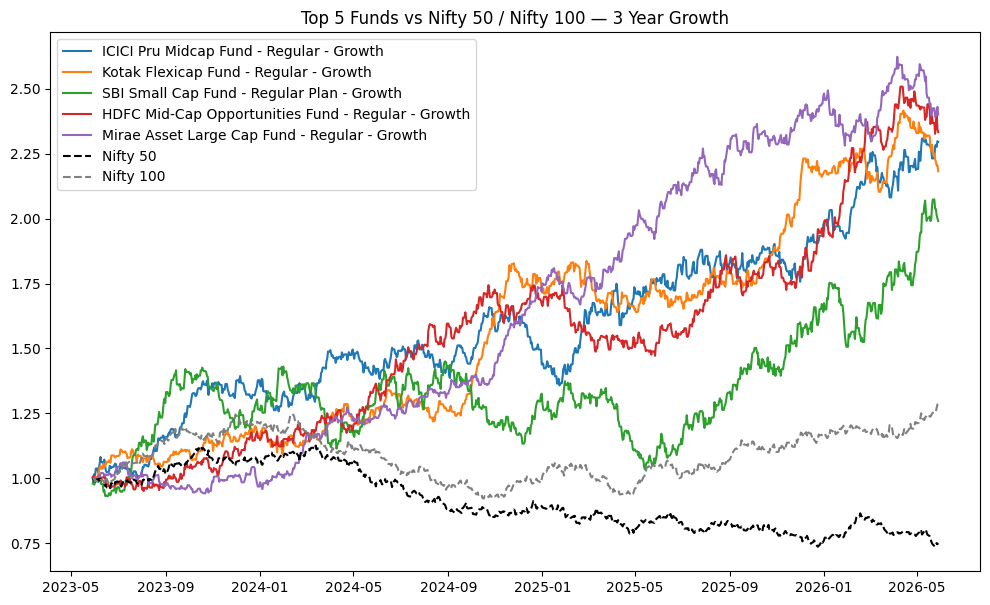

In [39]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 7))
for code, name in zip(top5_codes, top5_names):
    fund_data = nav[(nav['amfi_code'] == code) & (nav['date'] >= three_yr_start)].sort_values('date')
    growth = (1 + fund_data['daily_return'].fillna(0)).cumprod()
    ax.plot(fund_data['date'], growth, label=name)
nifty50_growth = (1 + nifty50['benchmark_return'].fillna(0)).cumprod()
nifty100_growth = (1 + nifty100_3yr['benchmark_return'].fillna(0)).cumprod()
ax.plot(nifty50['date'], nifty50_growth, label='Nifty 50', color='black', linestyle='--')
ax.plot(nifty100_3yr['date'], nifty100_growth, label='Nifty 100', color='gray', linestyle='--')
ax.set_title('Top 5 Funds vs Nifty 50 / Nifty 100 — 3 Year Growth')
ax.legend()
plt.savefig('benchmark_comparison_chart.png', dpi=150)
plt.show()

### ***Tracking Errors***

In [40]:
tracking_errors = []
for code, name in zip(top5_codes, top5_names):
    fund_data = nav[(nav['amfi_code'] == code) & (nav['date'] >= three_yr_start)][['date', 'daily_return']]
    merged = fund_data.merge(nifty100_3yr[['date', 'benchmark_return']], on='date', how='inner')
    diff = merged['daily_return'] - merged['benchmark_return']
    tracking_error = diff.std() * np.sqrt(252)
    tracking_errors.append({'scheme_name': name, 'tracking_error_vs_nifty100': tracking_error})
tracking_df = pd.DataFrame(tracking_errors)
print(tracking_df)

                                         scheme_name  \
0           ICICI Pru Midcap Fund - Regular - Growth   
1             Kotak Flexicap Fund - Regular - Growth   
2         SBI Small Cap Fund - Regular Plan - Growth   
3  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
4      Mirae Asset Large Cap Fund - Regular - Growth   

   tracking_error_vs_nifty100  
0                    0.232661  
1                    0.206540  
2                    0.286689  
3                    0.224976  
4                    0.187974  
